# In Class May 19

In [1]:
# importing libraries
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

### Importing the data

In [2]:
# importing mnist data from keras
(X_train, y_train), (X_test, y_test) = keras.datasets.mnist.load_data()

print("Training data shape:", X_train.shape)
print("Test data shape:", X_test.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Training data shape: (60000, 28, 28)
Test data shape: (10000, 28, 28)


### Visualizing the data

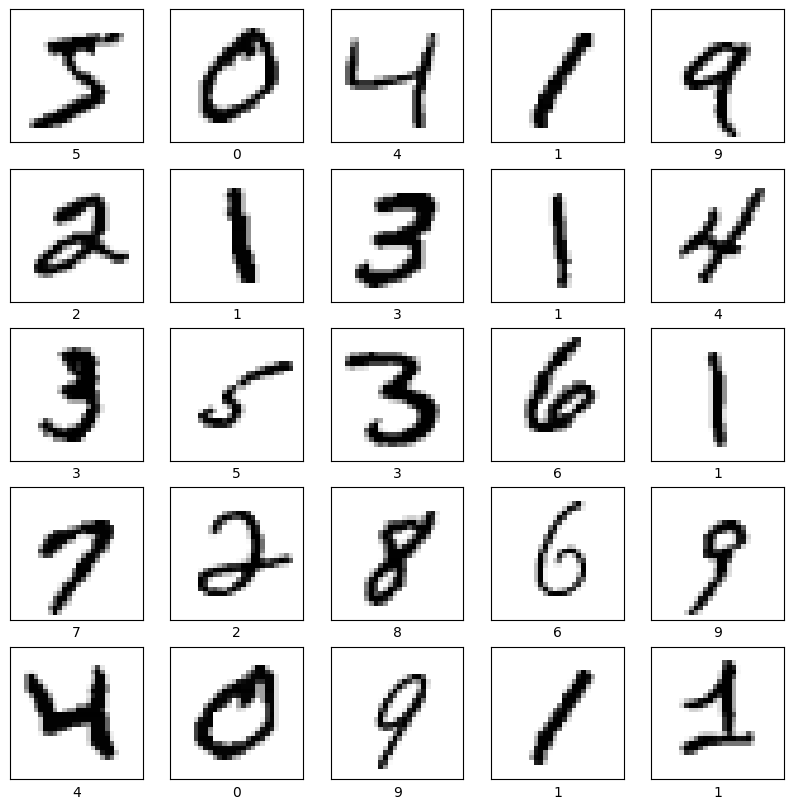

In [3]:
# visualize some of the data
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 10))
for i in range(25):
    plt.subplot(5, 5, i + 1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(X_train[i], cmap=plt.cm.binary)
    plt.xlabel(y_train[i])
plt.show()

### Preprocessing data for MLP

In [4]:

# Normalize pixel values to 0–1
X_train_norm = X_train / 255.0   # scale pixel values from 0–255 → 0–1
X_test_norm = X_test / 255.0     # apply same scaling to test data

# Flatten images for the MLP
X_train_flat = X_train_norm.reshape(X_train.shape[0], -1)  # # reshape from (60000, 28, 28) → (60000, 784)
X_test_flat = X_test_norm.reshape(X_test.shape[0], -1)     # same transformation for test images

print(X_train_flat.shape)
print(X_test_flat.shape)

(60000, 784)
(10000, 784)


### Building the MLP model

In [5]:
# Define the MLP baseline model
mlp_model = keras.Sequential([
    layers.Input(shape=(784,)),                 # input is a flattened image (784 pixels)
    layers.Dense(128, activation="relu"),       # hidden layer with 128 neurons (learns patterns)
    layers.Dense(64, activation="relu"),        # second hidden layer for more complex patterns
    layers.Dense(10, activation="softmax"),     # output layer (10 classes for digits 0–9)
])

# Compile the MLP model
mlp_model.compile(
    optimizer="adam",                           # optimization algorithm for training
    loss="sparse_categorical_crossentropy",     # loss for multi-class classification with integer labels
    metrics=["accuracy"]                        # track accuracy during training
)

# summary of the MLP model architecture
mlp_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

In [6]:
# train the MLP model
history_mlp = mlp_model.fit(
    X_train_flat,                               # flattened training images
    y_train,                                    # labels (0–9)
    epochs=5,                                   # number of training passes through data
    batch_size=128,                             # number of samples per training step
    validation_split=0.1                        # use 10% of training data for validation
)

# evaluate the MLP model on test data
test_loss_mlp, test_acc_mlp = mlp_model.evaluate(X_test_flat, y_test, verbose=2)
print(f"MLP Test accuracy: {test_acc_mlp:.4f}")

Epoch 1/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.9012 - loss: 0.3450 - val_accuracy: 0.9627 - val_loss: 0.1415
Epoch 2/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9573 - loss: 0.1451 - val_accuracy: 0.9657 - val_loss: 0.1166
Epoch 3/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9701 - loss: 0.1001 - val_accuracy: 0.9688 - val_loss: 0.1033
Epoch 4/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9767 - loss: 0.0765 - val_accuracy: 0.9723 - val_loss: 0.0929
Epoch 5/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9817 - loss: 0.0613 - val_accuracy: 0.9788 - val_loss: 0.0765
313/313 - 1s - 2ms/step - accuracy: 0.9773 - loss: 0.0763
MLP Test accuracy: 0.9773


### Preparing data for CNN

In [7]:
X_train_cnn = X_train_norm[..., np.newaxis]  # add channel dimension → (60000, 28, 28, 1)
X_test_cnn = X_test_norm[..., np.newaxis]    # same for test data

print("CNN input shape:", X_train_cnn.shape)  # confirm new shape for CNN

CNN input shape: (60000, 28, 28, 1)


### Building the CNN model

In [8]:
# define the model

cnn_model = models.Sequential([
    layers.Input(shape=(28,28,1)),                # input is 28x28 image with 1 channel (grayscale)
    layers.Conv2D(32, (3,3), activation="relu"),  # apply 32 filters to detect local patterns (edges, curves)
    layers.MaxPooling2D((2,2)),                   # reduce spatial size (summarize important features)
    layers.Flatten(),                             # convert feature maps into a vector
    layers.Dense(64, activation="relu"),          # combine extracted features into higher-level patterns
    layers.Dense(10, activation="softmax"),       # output probabilities for digits 0–9
])

In [9]:
# compile the model
cnn_model.compile(
    optimizer="adam",                             # optimization algorithm
    loss="sparse_categorical_crossentropy",       # loss for multi-class classification
    metrics=["accuracy"]                          # track accuracy during training
)

# train the model
cnn_history = cnn_model.fit(
    X_train_cnn,                                  # image data with spatial structure
    y_train,                                      # labels (correct digits)
    epochs=5,                                     # number of passes through the dataset
    validation_split=0.1                          # use 10% of training data for validation
)


Epoch 1/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 31s 17ms/step - accuracy: 0.9502 - loss: 0.1699 - val_accuracy: 0.9830 - val_loss: 0.0611
Epoch 2/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 28s 17ms/step - accuracy: 0.9817 - loss: 0.0592 - val_accuracy: 0.9840 - val_loss: 0.0638
Epoch 3/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 28s 16ms/step - accuracy: 0.9875 - loss: 0.0391 - val_accuracy: 0.9890 - val_loss: 0.0500
Epoch 4/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 28s 16ms/step - accuracy: 0.9908 - loss: 0.0284 - val_accuracy: 0.9863 - val_loss: 0.0472
Epoch 5/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 42s 17ms/step - accuracy: 0.9938 - loss: 0.0202 - val_accuracy: 0.9882 - val_loss: 0.0499


### Evaluating the CNN model

In [10]:
# Evaluate the CNN on test data
cnn_loss, cnn_acc = cnn_model.evaluate(X_test_cnn, y_test)  # evaluate on unseen test data
print("CNN Test Accuracy:", cnn_acc)                        # report final test accuracy

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9875 - loss: 0.0410
CNN Test Accuracy: 0.987500011920929


### MLP vs CNN model

In [11]:
# Compare the CNN's performance to the MLP baseline
print(f"MLP Test accuracy: {test_acc_mlp:.4f}")
print(f"CNN Test accuracy: {cnn_acc:.4f}")


MLP Test accuracy: 0.9773
CNN Test accuracy: 0.9875


### Visualizing model training

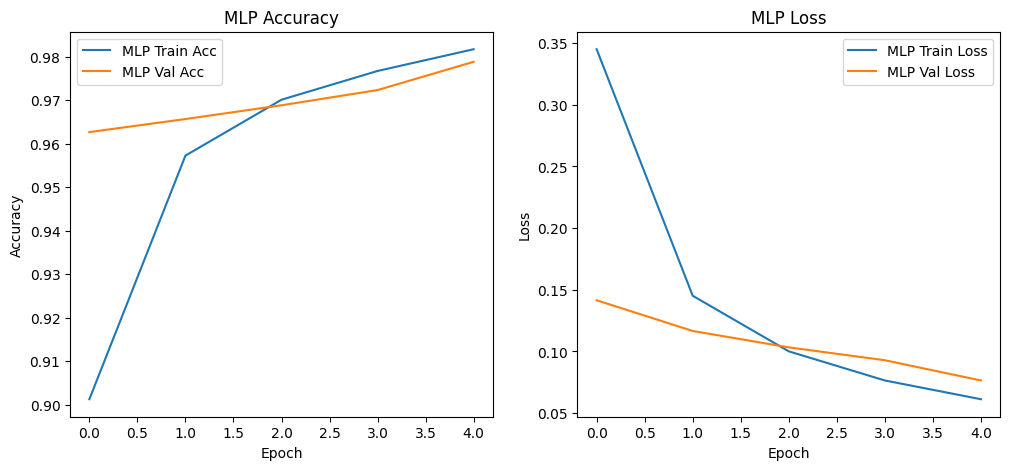

In [12]:
# Plot training history for MLP (accuracy over epochs and loss over epochs)
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history_mlp.history['accuracy'], label='MLP Train Acc')
plt.plot(history_mlp.history['val_accuracy'], label='MLP Val Acc')
plt.title('MLP Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_mlp.history['loss'], label='MLP Train Loss')
plt.plot(history_mlp.history['val_loss'], label='MLP Val Loss')
plt.title('MLP Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()


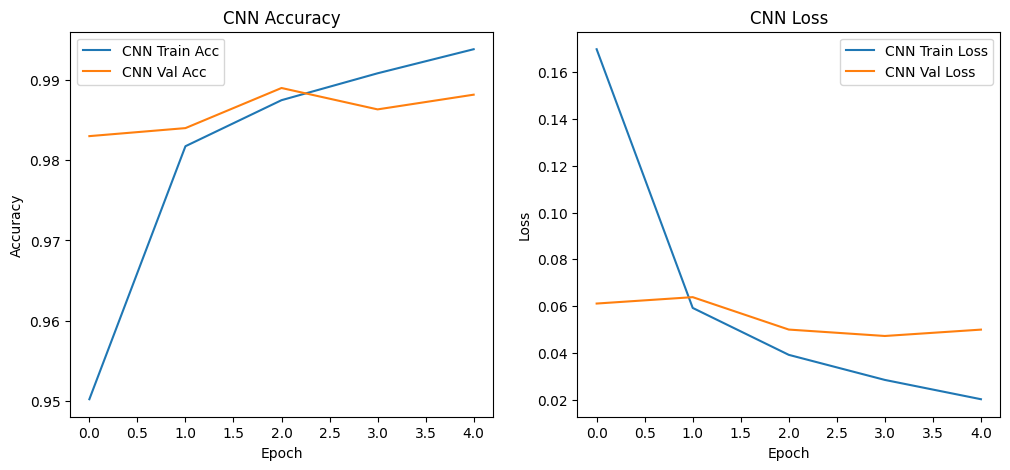

In [13]:
# plot training history for CNN (accuracy over epochs and loss over epochs)
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(cnn_history.history['accuracy'], label='CNN Train Acc')
plt.plot(cnn_history.history['val_accuracy'], label='CNN Val Acc')
plt.title('CNN Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(cnn_history.history['loss'], label='CNN Train Loss')
plt.plot(cnn_history.history['val_loss'], label='CNN Val Loss')
plt.title('CNN Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step


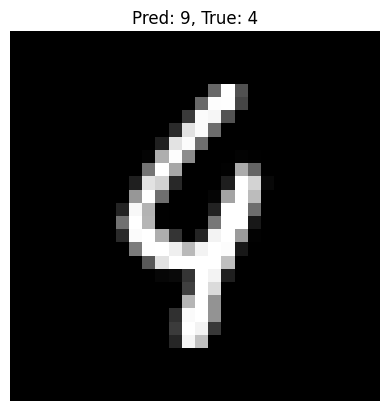

In [14]:
# Get predictions
cnn_predictions = cnn_model.predict(X_test_cnn)

# Find a misclassified example
for i in range(len(X_test)):
    pred = np.argmax(cnn_predictions[i])  # predicted class

    if pred != y_test[i]:                 # compare to true label
        plt.imshow(X_test[i], cmap="gray")
        plt.title(f"Pred: {pred}, True: {y_test[i]}")
        plt.axis("off")
        break

### How well do the models perform if we rotate the images?

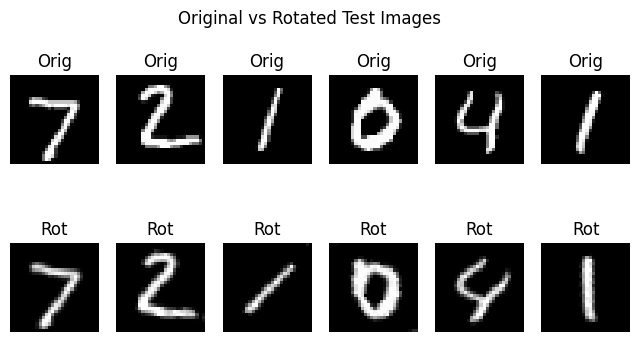

In [15]:
# Visualize rotated test images (to see what changed)

rotation_layer_eval = tf.keras.layers.RandomRotation(0.15)

X_test_rot_eval_cnn = rotation_layer_eval(X_test_cnn, training=True)

plt.figure(figsize=(8, 4))

for i in range(6):
    # Original
    plt.subplot(2, 6, i + 1)
    plt.imshow(X_test[i], cmap='gray')
    plt.title("Orig")
    plt.axis('off')

    # Rotated
    plt.subplot(2, 6, i + 7)
    plt.imshow(X_test_rot_eval_cnn[i].numpy().squeeze(), cmap='gray')
    plt.title("Rot")
    plt.axis('off')

plt.suptitle("Original vs Rotated Test Images")
plt.show()

In [16]:
# Flatten rotated images for MLP
X_test_rot_eval_flat = X_test_rot_eval_cnn.numpy().reshape(X_test.shape[0], -1)

# Evaluate original models on rotated data
mlp_rot_eval_loss, mlp_rot_eval_acc = mlp_model.evaluate(X_test_rot_eval_flat, y_test)
cnn_rot_eval_loss, cnn_rot_eval_acc = cnn_model.evaluate(X_test_rot_eval_cnn, y_test)

print("MLP accuracy (original test):", test_acc_mlp)
print("MLP accuracy (rotated test):", mlp_rot_eval_acc)

print("CNN accuracy (original test):", cnn_acc)
print("CNN accuracy (rotated test):", cnn_rot_eval_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7037 - loss: 1.5090
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.7627 - loss: 1.1998
MLP accuracy (original test): 0.9772999882698059
MLP accuracy (rotated test): 0.7037000060081482
CNN accuracy (original test): 0.987500011920929
CNN accuracy (rotated test): 0.7627000212669373


### New models trained with data augmentation (random rotations)

In [17]:
# Create rotated datasets for retraining models
rotation_layer_train = tf.keras.layers.RandomRotation(0.15)

X_train_rot_train_cnn = rotation_layer_train(X_train_cnn, training=True)  # rotated training images for CNN
X_test_rot_train_cnn = rotation_layer_train(X_test_cnn, training=True)    # rotated test images for CNN

# Flatten rotated datasets for MLP
X_train_rot_train_flat = X_train_rot_train_cnn.numpy().reshape(X_train.shape[0], -1)
X_test_rot_train_flat = X_test_rot_train_cnn.numpy().reshape(X_test.shape[0], -1)

### Use the code cell below to build, train and evaluate an MLP model using the rotated data (X_train_rot_train_flat and X_test_rot_train_flat)

In [18]:
mlp_rot = keras.Sequential([
    layers.Input(shape=(784,)),
    layers.Dense(128, activation="relu"),
    layers.Dense(64, activation="relu"),
    layers.Dense(10, activation="softmax"),
])

mlp_rot.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

history_mlp_rot = mlp_rot.fit(
    X_train_rot_train_flat, y_train,
    epochs=5, batch_size=128, validation_split=0.1
)

mlp_rot_loss, mlp_rot_acc = mlp_rot.evaluate(X_test_rot_train_flat, y_test, verbose=2)
print(f"MLP (trained on rotated) test acc: {mlp_rot_acc:.4f}")

Epoch 1/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.8244 - loss: 0.5865 - val_accuracy: 0.9152 - val_loss: 0.2758
Epoch 2/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9198 - loss: 0.2653 - val_accuracy: 0.9423 - val_loss: 0.1989
Epoch 3/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9396 - loss: 0.2005 - val_accuracy: 0.9462 - val_loss: 0.1798
Epoch 4/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9508 - loss: 0.1601 - val_accuracy: 0.9527 - val_loss: 0.1535
Epoch 5/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9582 - loss: 0.1358 - val_accuracy: 0.9500 - val_loss: 0.1522
313/313 - 1s - 2ms/step - accuracy: 0.9454 - loss: 0.1836
MLP (trained on rotated) test acc: 0.9454


### Use the code cell below to build, train and evaluate a CNN model using the rotated data (X_train_rot_train_cnn and X_test_rot_train_cnn)

Epoch 1/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 30s 17ms/step - accuracy: 0.8829 - loss: 0.3798 - val_accuracy: 0.9483 - val_loss: 0.1631
Epoch 2/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 29s 17ms/step - accuracy: 0.9514 - loss: 0.1590 - val_accuracy: 0.9668 - val_loss: 0.1155
Epoch 3/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 30s 17ms/step - accuracy: 0.9635 - loss: 0.1151 - val_accuracy: 0.9677 - val_loss: 0.1007
Epoch 4/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 28s 17ms/step - accuracy: 0.9726 - loss: 0.0863 - val_accuracy: 0.9670 - val_loss: 0.1029
Epoch 5/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 28s 17ms/step - accuracy: 0.9795 - loss: 0.0668 - val_accuracy: 0.9732 - val_loss: 0.0912
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9674 - loss: 0.1107
CNN (trained on rotated) test acc: 0.9674


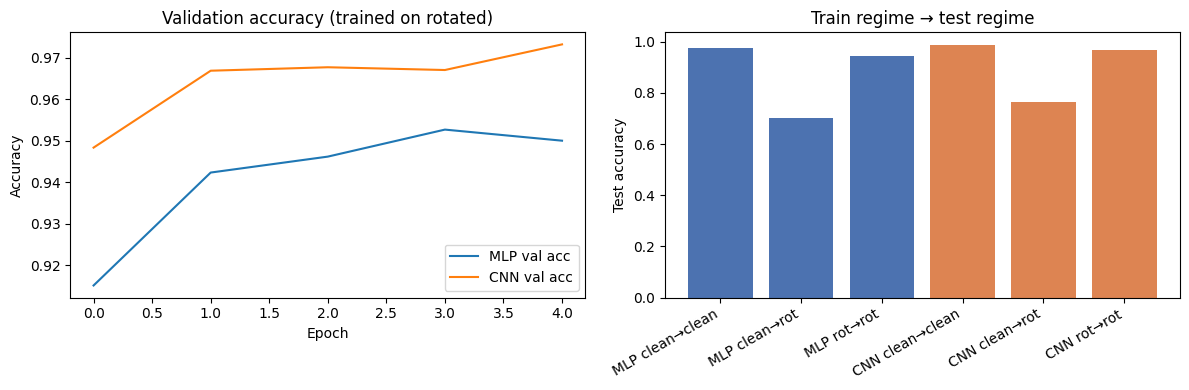

In [19]:
cnn_rot = models.Sequential([
    layers.Input(shape=(28,28,1)),
    layers.Conv2D(32, (3,3), activation="relu"),
    layers.MaxPooling2D((2,2)),
    layers.Flatten(),
    layers.Dense(64, activation="relu"),
    layers.Dense(10, activation="softmax"),
])

cnn_rot.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

history_cnn_rot = cnn_rot.fit(
    X_train_rot_train_cnn, y_train,
    epochs=5, validation_split=0.1
)

cnn_rot_loss, cnn_rot_acc = cnn_rot.evaluate(X_test_rot_train_cnn, y_test)
print(f"CNN (trained on rotated) test acc: {cnn_rot_acc:.4f}")

# Comparison chart for the markdown below
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history_mlp_rot.history['val_accuracy'], label='MLP val acc')
axes[0].plot(history_cnn_rot.history['val_accuracy'], label='CNN val acc')
axes[0].set_title('Validation accuracy (trained on rotated)')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Accuracy'); axes[0].legend()

labels = ['MLP clean→clean', 'MLP clean→rot', 'MLP rot→rot',
          'CNN clean→clean', 'CNN clean→rot', 'CNN rot→rot']
vals = [test_acc_mlp, mlp_rot_eval_acc, mlp_rot_acc,
        cnn_acc, cnn_rot_eval_acc, cnn_rot_acc]
axes[1].bar(range(6), vals, color=['#4c72b0']*3 + ['#dd8452']*3)
axes[1].set_xticks(range(6)); axes[1].set_xticklabels(labels, rotation=30, ha='right')
axes[1].set_ylabel('Test accuracy'); axes[1].set_title('Train regime → test regime')
plt.tight_layout(); plt.show()

### Using the markdown cell below evaluate the performance of the MLP vs the CNN. Use graphs and metrics to support your evaluation.